# V-JEPA 2 Demo Notebook

This tutorial provides an example of how to load the V-JEPA 2 model in vanilla PyTorch and HuggingFace, extract a video embedding, and then predict an action class. For more details about the paper and model weights, please see https://github.com/facebookresearch/vjepa2.

First, let's import the necessary libraries and load the necessary functions for this tutorial.

In [1]:
import json
import os
import subprocess
import sys
import matplotlib.pyplot as plt

parent_dir = os.path.abspath("..")
checkpoint_dir = os.path.abspath("../../../checkpoints")
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
    
sample_video_path = "P01_101_6fps.mp4"

import numpy as np
import torch
import torch.nn.functional as F
from decord import VideoReader
from transformers import AutoVideoProcessor, AutoModel

import src.datasets.utils.video.transforms as video_transforms
import src.datasets.utils.video.volume_transforms as volume_transforms
from src.models.attentive_pooler import AttentiveClassifier
from src.models.vision_transformer import vit_large_rope

IMAGENET_DEFAULT_MEAN = (0.485, 0.456, 0.406)
IMAGENET_DEFAULT_STD = (0.229, 0.224, 0.225)

def load_pretrained_vjepa_pt_weights(model, pretrained_weights):
    # Load weights of the VJEPA2 encoder
    # The PyTorch state_dict is already preprocessed to have the right key names
    pretrained_dict = torch.load(pretrained_weights, weights_only=True, map_location="cpu")["encoder"]
    pretrained_dict = {k.replace("module.", ""): v for k, v in pretrained_dict.items()}
    pretrained_dict = {k.replace("backbone.", ""): v for k, v in pretrained_dict.items()}
    msg = model.load_state_dict(pretrained_dict, strict=False)
    print("Pretrained weights found at {} and loaded with msg: {}".format(pretrained_weights, msg))


def load_pretrained_vjepa_classifier_weights(model, pretrained_weights):
    # Load weights of the VJEPA2 classifier
    # The PyTorch state_dict is already preprocessed to have the right key names
    pretrained_dict = torch.load(pretrained_weights, weights_only=True, map_location="cpu")["classifiers"][0]
    pretrained_dict = {k.replace("module.", ""): v for k, v in pretrained_dict.items()}
    msg = model.load_state_dict(pretrained_dict, strict=False)
    print("Pretrained weights found at {} and loaded with msg: {}".format(pretrained_weights, msg))


def build_pt_video_transform(img_size):
    short_side_size = int(256.0 / 224 * img_size)
    # Eval transform has no random cropping nor flip
    eval_transform = video_transforms.Compose(
        [
            video_transforms.Resize(short_side_size, interpolation="bilinear"),
            video_transforms.CenterCrop(size=(img_size, img_size)),
            volume_transforms.ClipToTensor(),
            video_transforms.Normalize(mean=IMAGENET_DEFAULT_MEAN, std=IMAGENET_DEFAULT_STD),
        ]
    )
    return eval_transform


def get_video(start, end, inc):
    vr = VideoReader(sample_video_path)
    
    # choosing some frames here, you can define more complex sampling strategy
    frame_idx = np.arange(start, end, inc)
    video = vr.get_batch(frame_idx).asnumpy()
    return video


def forward_vjepa_video(model_pt, pt_transform, start, end, inc):
    # Run a sample inference with VJEPA
    with torch.inference_mode():
        # Read and pre-process the image
        video = get_video(start, end, inc)  # T x H x W x C
        video = torch.from_numpy(video).permute(0, 3, 1, 2)  # T x C x H x W
        x_pt = pt_transform(video).cuda().unsqueeze(0)
        # Extract the patch-wise features from the last layer
        out_patch_features_pt = model_pt(x_pt)

    return out_patch_features_pt


def get_vjepa_video_classification_results(classifier, out_patch_features_pt):
    SOMETHING_SOMETHING_V2_CLASSES = json.load(open("ssv2_classes.json", "r"))

    with torch.inference_mode():
        out_classifier = classifier(out_patch_features_pt)

    print(f"Classifier output shape: {out_classifier.shape}")

    print("Top 5 predicted class names:")
    top5_indices = out_classifier.topk(5).indices[0]
    top5_probs = F.softmax(out_classifier.topk(5).values[0]) * 100.0  # convert to percentage
    for idx, prob in zip(top5_indices, top5_probs):
        str_idx = str(idx.item())
        print(f"{SOMETHING_SOMETHING_V2_CLASSES[str_idx]} ({prob}%)")

    return

/home/jefferyfan/anaconda3/envs/exp/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Next, let's download a sample video to the local repository. If the video is already downloaded, the code will skip this step. Likewise, let's download a mapping for the action recognition classes used in Something-Something V2, so we can interpret the predicted action class from our model.

In [2]:
#sample_video_path = "room16fps.mp4"
# Download the video if not yet downloaded to local path
if not os.path.exists(sample_video_path):
    video_url = "https://huggingface.co/datasets/nateraw/kinetics-mini/resolve/main/val/bowling/-WH-lxmGJVY_000005_000015.mp4"
    command = ["wget", video_url, "-O", sample_video_path]
    subprocess.run(command)
    print("Downloading video")

# Download SSV2 classes if not already present
ssv2_classes_path = "ssv2_classes.json"
if not os.path.exists(ssv2_classes_path):
    command = [
        "wget",
        "https://huggingface.co/datasets/huggingface/label-files/resolve/d79675f2d50a7b1ecf98923d42c30526a51818e2/"
        "something-something-v2-id2label.json",
        "-O",
        "ssv2_classes.json",
    ]
    subprocess.run(command)
    print("Downloading SSV2 classes")

Now, let's load the models in both vanilla Pytorch as well as through the HuggingFace API. Note that HuggingFace API will automatically load the weights through `from_pretrained()`, so there is no additional download required for HuggingFace.

To download the PyTorch model weights, use wget and specify your preferred target path. See the README for the model weight URLs.
E.g. 
```
wget https://dl.fbaipublicfiles.com/vjepa2/vitg-384.pt -P YOUR_DIR
```
Then update `pt_model_path` with `YOUR_DIR/vitg-384.pt`. Also note that you have the option to use `torch.hub.load`.

In [3]:
# HuggingFace model repo name
#hf_model_name = (
#    "facebook/vjepa2-vitl-fpc64-256"  # Replace with your favored model, e.g. facebook/vjepa2-vitg-fpc64-384
#)
# Path to local PyTorch weights
model_name = "vjepa2_1_vitl_dist_vitG_384.pt"
pt_model_path = os.path.join(checkpoint_dir, model_name)

# Initialize the HuggingFace model, load pretrained weights
#model_hf = AutoModel.from_pretrained(hf_model_name)
#model_hf.cuda().eval()

# Build HuggingFace preprocessing transform
#hf_transform = AutoVideoProcessor.from_pretrained(hf_model_name)
img_size = 384  # E.g. 384, 256, etc.

# Initialize the PyTorch model, load pretrained weights
model_pt = vit_large_rope(img_size=(img_size, img_size), num_frames=64)
model_pt.cuda().eval()
load_pretrained_vjepa_pt_weights(model_pt, pt_model_path)

### Can also use torch.hub to load the model
#model_pt, _ = torch.hub.load('facebookresearch/vjepa2', 'vjepa2_1_vit_large_384')
#model_pt.cuda().eval()

# Build PyTorch preprocessing transform
pt_video_transform = build_pt_video_transform(img_size=img_size)

Pretrained weights found at /home/jefferyfan/lab/EventSegmentation/checkpoints/vjepa2_1_vitl_dist_vitG_384.pt and loaded with msg: _IncompatibleKeys(missing_keys=['norm.weight', 'norm.bias'], unexpected_keys=['img_mod_embed', 'video_mod_embed', 'patch_embed_img.proj.weight', 'patch_embed_img.proj.bias', 'norms_block.0.weight', 'norms_block.0.bias', 'norms_block.1.weight', 'norms_block.1.bias', 'norms_block.2.weight', 'norms_block.2.bias', 'norms_block.3.weight', 'norms_block.3.bias'])


Now we can run the encoder on the video to get the patch-wise features from the last layer of the encoder. To verify that the HuggingFace and PyTorch models are equivalent, we will compare the values of the features.

In [4]:
# Inference on video to get the patch-wise features
out_patch_features_pt = forward_vjepa_video(
    model_pt, pt_video_transform, 0, 64, 1
)

print(
    f"""
    Inference results on video:
    PyTorch output shape:     {out_patch_features_pt.shape} 
    """
) # 384x384 with 16x16 patches results in 24x24=576 spatial patches, and 64 frams with 2-frame tubelet = 32 temporal steps, 32*576=18432, 1024 is the embedding dim

/home/jefferyfan/anaconda3/envs/exp/lib/python3.11/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)



    Inference results on video:
    PyTorch output shape:     torch.Size([1, 18432, 1024]) 
    


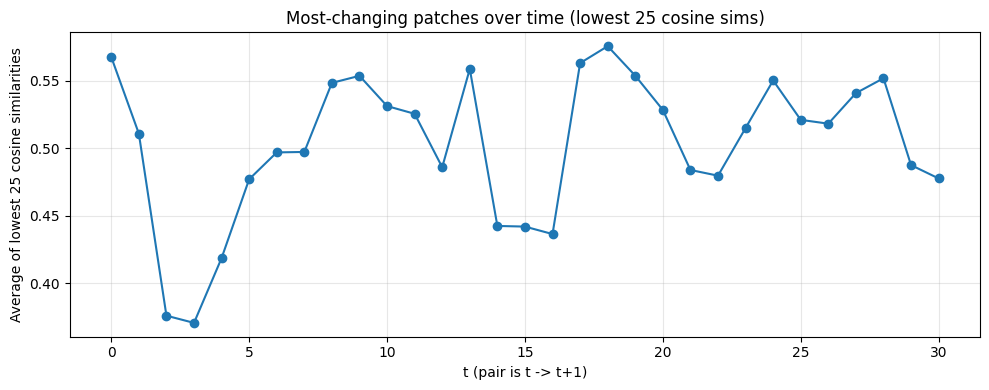

raw shape: (1, 18432, 1024)
reshaped features shape [T, N, D]: (32, 576, 1024)
cos_sims shape [T-1, N]: (31, 576)
lowest_25_avg_per_t shape [T-1]: (31,)
lowest_25_avg_per_t: tensor([0.5675, 0.5108, 0.3762, 0.3708, 0.4188, 0.4771, 0.4969, 0.4973, 0.5483,
        0.5536, 0.5312, 0.5255, 0.4860, 0.5587, 0.4425, 0.4421, 0.4365, 0.5630,
        0.5755, 0.5537, 0.5284, 0.4839, 0.4797, 0.5150, 0.5501, 0.5210, 0.5182,
        0.5408, 0.5518, 0.4875, 0.4777], device='cuda:0')


In [17]:
import torch
import matplotlib.pyplot as plt

raw = out_patch_features_pt
num_temporal = 32

# Normalize to [T, N, D]
if raw.dim() == 4:
    # [B, T, N, D] -> assume B=1 for this notebook flow
    if raw.shape[0] != 1:
        raise ValueError(f"Expected batch size 1, got {raw.shape[0]}")
    features = raw[0]
elif raw.dim() == 3 and raw.shape[0] == 1:
    # [1, T*N, D] -> infer T and N
    flat = raw[0]  # [T*N, D]
    total_tokens, D = flat.shape

    if "num_temporal" in globals() and isinstance(num_temporal, int) and num_temporal > 1 and total_tokens % num_temporal == 0:
        T = num_temporal
        N = total_tokens // T
    else:
        raise ValueError(
            f"Cannot infer temporal steps from shape {tuple(raw.shape)}. "
            "Set num_temporal in a previous cell or reshape manually."
        )

    features = flat.view(T, N, D)
elif raw.dim() == 3:
    # Already [T, N, D]
    features = raw
else:
    raise ValueError(
        f"Expected out_patch_features_pt to be [T, N, D], [1, T, N, D], or [1, T*N, D], got {tuple(raw.shape)}"
    )

T, N, D = features.shape
if T < 2:
    raise ValueError(f"Need at least 2 timesteps, got {T}")
if N < 25:
    raise ValueError(f"Need at least 25 patches, got {N}")

# Cosine similarity for same patch index between consecutive timesteps
f_t = features[:-1]   # [T-1, N, D]
f_t1 = features[1:]   # [T-1, N, D]
cos_sims = torch.nn.functional.cosine_similarity(f_t, f_t1, dim=-1)  # [T-1, N]

# Lowest 25 per timestep pair, then average
k = 25
lowest_25_vals, lowest_25_idx = torch.topk(cos_sims, k=k, dim=1, largest=False)
lowest_25_avg_per_t = lowest_25_vals.mean(dim=1)  # [T-1]

# Plot per timestep
plt.figure(figsize=(10, 4))
plt.plot(range(T - 1), lowest_25_avg_per_t.detach().cpu().numpy(), marker='o', linewidth=1.5)
plt.xlabel('t (pair is t -> t+1)')
plt.ylabel('Average of lowest 25 cosine similarities')
plt.title('Most-changing patches over time (lowest 25 cosine sims)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"raw shape: {tuple(raw.shape)}")
print(f"reshaped features shape [T, N, D]: {tuple(features.shape)}")
print(f"cos_sims shape [T-1, N]: {tuple(cos_sims.shape)}")
print(f"lowest_25_avg_per_t shape [T-1]: {tuple(lowest_25_avg_per_t.shape)}")
print("lowest_25_avg_per_t:", lowest_25_avg_per_t)